# ESZA019 – Visão Computacional  
## Laboratório 5 – Câmera Estéreo

**Integrantes:**  
-Luana Fernandes Recucci RA 11202020038

-Lucas Merino RA 11201721004

-Victor Parpinelli Ananias da Silva RA 11072516  

**Data de realização do experimento:** 08/07/2026  
**Data de publicação do relatório:** 13/07/2026  

## 1. Introdução

A visão estereoscópica busca reproduzir computacionalmente a percepção de profundidade do sistema visual humano. Para isso, duas câmeras observam a mesma cena a partir de posições ligeiramente diferentes. Um ponto tridimensional é projetado em posições distintas nas imagens esquerda e direita, e essa diferença permite estimar sua profundidade.

No experimento, duas webcams foram fixadas sobre uma estrutura rígida e mantidas paralelas. Inicialmente, foram obtidas imagens simultâneas de um tabuleiro de calibração. Em seguida, as câmeras foram calibradas individualmente e em conjunto. Os parâmetros obtidos foram utilizados para corrigir distorções, retificar as imagens e gerar uma composição anáglifa, visualizada com óculos de lentes ciano e vermelha.

## 2. Fundamentação teórica

### 2.1 Epipolos

Considere duas câmeras com centros ópticos \(C_L\) e \(C_R\). A linha que une esses centros é chamada de **linha de base**. O epipolo de uma imagem corresponde à projeção do centro óptico da outra câmera sobre seu plano de imagem.

Assim:

- o epipolo esquerdo é a projeção de \(C_R\) no plano da câmera esquerda;
- o epipolo direito é a projeção de \(C_L\) no plano da câmera direita.

Os epipolos podem estar dentro ou fora dos limites visíveis da imagem, dependendo da disposição relativa das câmeras.

### 2.2 Plano epipolar

Para um ponto tridimensional \(P\), o plano formado por \(P\), \(C_L\) e \(C_R\) é denominado **plano epipolar**. Como os dois centros ópticos pertencem a esse plano, ele também contém a linha de base.

### 2.3 Linhas epipolares

A interseção do plano epipolar com cada plano de imagem forma uma linha epipolar. Quando um ponto é identificado em uma imagem, seu ponto correspondente na outra imagem deve estar localizado sobre a linha epipolar correspondente. Essa restrição reduz a busca de correspondência de uma região bidimensional para uma linha.

Após a retificação, as linhas epipolares tornam-se aproximadamente horizontais. Consequentemente, pontos correspondentes devem apresentar coordenadas verticais semelhantes.

### 2.4 Matriz fundamental

A matriz fundamental \(F\) é uma matriz \(3 \times 3\) que representa a geometria epipolar entre duas câmeras não calibradas. Para pontos correspondentes homogêneos \(\mathbf{x}_L\) e \(\mathbf{x}_R\), vale:

\[
\mathbf{x}_R^T F \mathbf{x}_L = 0
\]

A matriz contém nove elementos, mas possui posto 2 e é definida a menos de um fator de escala. Portanto, possui sete graus de liberdade independentes.

### 2.5 Disparidade estereoscópica

A disparidade é a diferença entre as posições horizontais de pontos correspondentes nas imagens retificadas:

\[
d = x_L - x_R
\]

Em um sistema ideal, a profundidade \(Z\) é aproximadamente dada por:

\[
Z = \frac{fB}{d}
\]

em que \(f\) é a distância focal, \(B\) é a distância entre os centros ópticos e \(d\) é a disparidade. Assim, objetos próximos apresentam maior disparidade, enquanto objetos distantes apresentam menor disparidade.

## 3. Parâmetros necessários para uma câmera estéreo

A calibração individual de cada câmera determina principalmente:

- matriz intrínseca da câmera esquerda, \(K_L\);
- matriz intrínseca da câmera direita, \(K_R\);
- coeficientes de distorção de cada lente;
- vetores de rotação e translação associados às imagens do tabuleiro.

Uma matriz intrínseca possui a forma:

\[
K =
\begin{bmatrix}
f_x & s & c_x\\
0 & f_y & c_y\\
0 & 0 & 1
\end{bmatrix}
\]

onde \(f_x\) e \(f_y\) são as distâncias focais em pixels, \(c_x\) e \(c_y\) formam o ponto principal e \(s\) representa a inclinação entre os eixos, normalmente considerada nula.

A calibração conjunta determina:

- matriz de rotação \(R\) entre as câmeras;
- vetor de translação \(T\);
- matriz essencial \(E\);
- matriz fundamental \(F\);
- matrizes de retificação;
- matrizes de projeção;
- matriz \(Q\), utilizada para reprojeção tridimensional.

Também são necessários o tamanho das imagens e a correspondência entre pontos tridimensionais do padrão e suas projeções bidimensionais.

## 4. Materiais e montagem experimental

Foram utilizados:

- duas webcams USB;
- computador com Python, OpenCV e Jupyter Notebook;
- suporte rígido para fixar as webcams;
- padrão quadriculado com **8 × 6 cantos internos**;
- óculos 3D anáglifo com lentes vermelha e ciano.

As webcams foram posicionadas paralelamente e fixadas para impedir movimento relativo após a calibração. A distância entre seus eixos ópticos foi escolhida de modo a produzir uma diferença perceptível entre as imagens, sem prejudicar a região comum observada pelas duas câmeras. Neste caso usamos uma distância de 6.5 cm entre o eixo de cada câmera, medida a qual foi a média do eixo de visão dos integrantes do grupo.

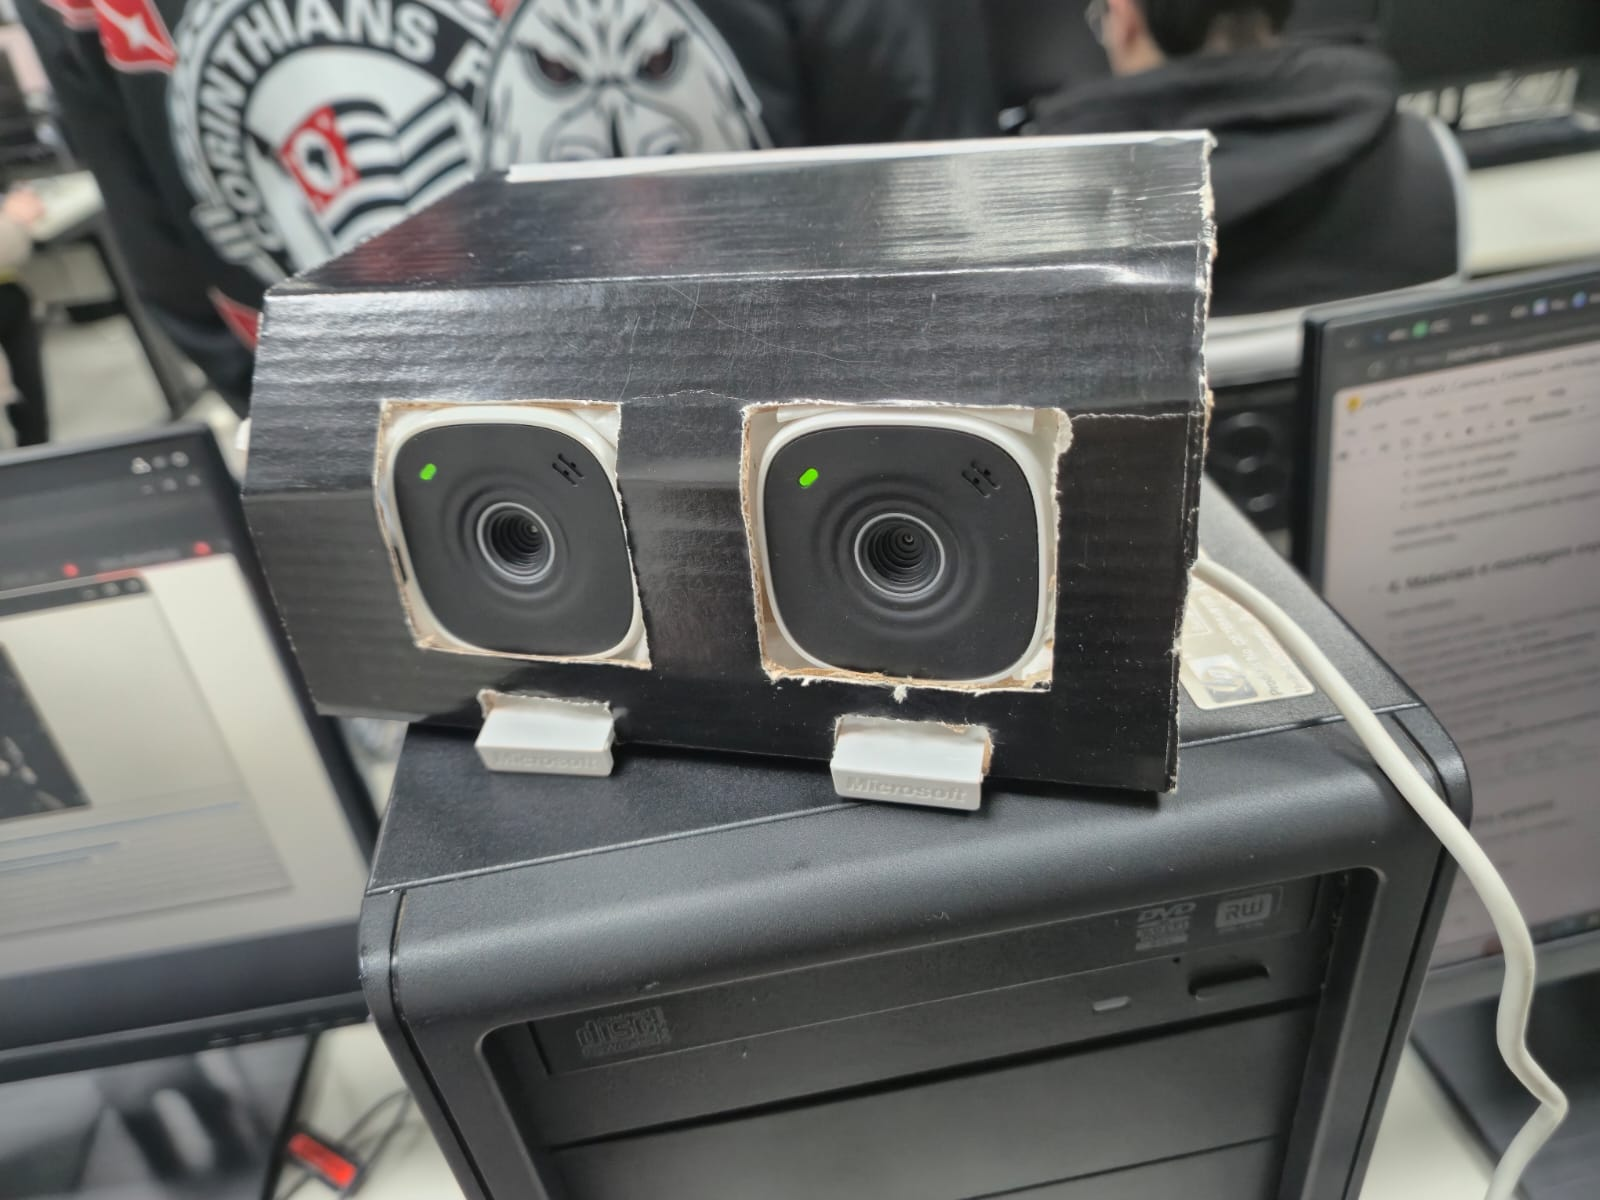

## 5. Verificação das webcams

Antes da captura estereoscópica, uma webcam foi testada individualmente. A célula abaixo abre a câmera e mostra suas imagens até que a tecla `q` seja pressionada.

In [ ]:
ID_CAMERA_TESTE = 1

cap = cv2.VideoCapture(ID_CAMERA_TESTE)

if not cap.isOpened():
    raise RuntimeError(
        f"Não foi possível abrir a câmera {ID_CAMERA_TESTE}. "
        "Teste os índices 0, 1 ou 2."
    )

while True:
    ret, frame = cap.read()
    if not ret:
        print("Não foi possível receber um quadro da câmera.")
        break

    cv2.imshow("Teste da webcam - pressione q para sair", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

## 6. Captura das imagens de calibração

Foram utilizadas as câmeras de índices 1 e 0. O programa detecta um tabuleiro de **8 × 6 cantos internos** nas duas imagens e, a cada cinco segundos, salva um par quando o padrão é detectado simultaneamente.

No roteiro foram solicitadas de 10 a 15 imagens. Porém tiramos em torno de 28 imagens para garantir uma melhor calibração, já que as câmeras utilizadas apresentavam um delay em relação uma a outra.

In [3]:
CAMERA_ESQUERDA = 1
CAMERA_DIREITA = 0
PADRAO = (8, 6)
INTERVALO_CAPTURA = 5
QUANTIDADE_DESEJADA = 15
IDENTIFICADOR_EQUIPE = "victor"

camL = cv2.VideoCapture(CAMERA_ESQUERDA)
camR = cv2.VideoCapture(CAMERA_DIREITA)

if not camL.isOpened() or not camR.isOpened():
    camL.release()
    camR.release()
    raise RuntimeError(
        "Não foi possível abrir as duas webcams. "
        "Verifique os índices CAMERA_ESQUERDA e CAMERA_DIREITA."
    )

inicio = time.time()
contador = 0

try:
    while contador < QUANTIDADE_DESEJADA:
        retL, frameL = camL.read()
        retR, frameR = camR.read()

        if not retL or not retR:
            print("Falha na leitura de uma das câmeras.")
            break

        grayL = cv2.cvtColor(frameL, cv2.COLOR_BGR2GRAY)
        grayR = cv2.cvtColor(frameR, cv2.COLOR_BGR2GRAY)

        encontrouL, cornersL = cv2.findChessboardCorners(grayL, PADRAO, None)
        encontrouR, cornersR = cv2.findChessboardCorners(grayR, PADRAO, None)

        tempo_restante = max(0, INTERVALO_CAPTURA - int(time.time() - inicio))

        visualL = frameL.copy()
        visualR = frameR.copy()

        cv2.putText(
            visualL, f"Proxima captura: {tempo_restante}s",
            (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2
        )
        cv2.putText(
            visualR, f"Pares salvos: {contador}",
            (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2
        )

        if encontrouL:
            cv2.drawChessboardCorners(visualL, PADRAO, cornersL, encontrouL)
        if encontrouR:
            cv2.drawChessboardCorners(visualR, PADRAO, cornersR, encontrouR)

        cv2.imshow("Camera esquerda", visualL)
        cv2.imshow("Camera direita", visualR)

        if encontrouL and encontrouR and tempo_restante == 0:
            contador += 1

            nomeL = PASTA_ESQUERDA / f"{IDENTIFICADOR_EQUIPE}_img{contador}.png"
            nomeR = PASTA_DIREITA / f"{IDENTIFICADOR_EQUIPE}_img{contador}.png"

            cv2.imwrite(str(nomeL), frameL)
            cv2.imwrite(str(nomeR), frameR)

            print(f"Par {contador} salvo.")
            inicio = time.time()

        if cv2.waitKey(1) & 0xFF == 27:
            print("Captura encerrada pelo usuário.")
            break
finally:
    camL.release()
    camR.release()
    cv2.destroyAllWindows()

print(f"Total de pares salvos: {contador}")

<class 'NameError'>: name 'cv2' is not defined

### 7.1 Análise da captura

Durante a captura, o tabuleiro deve ocupar diferentes regiões e inclinações da imagem. Isso fornece informações suficientes para estimar a distorção e os parâmetros internos das câmeras. Fotografias muito semelhantes entre si, desfocadas ou com o padrão parcialmente oculto reduzem a qualidade da calibração.

> *Exemplo imagem número 19 lado esquerdo*
> 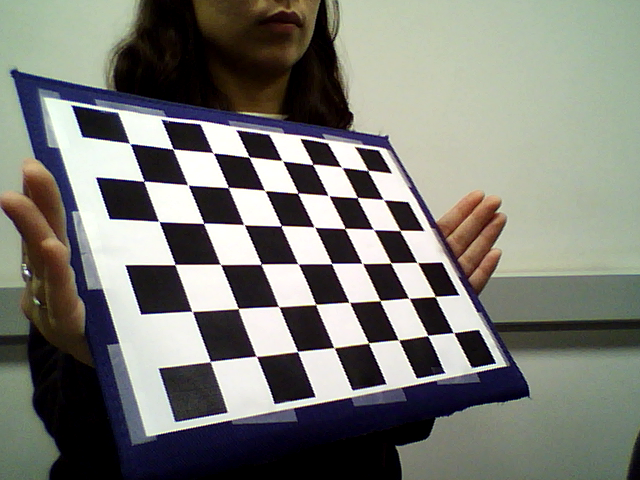
>
> *Exemplo imagem número 19 lado direito*
> 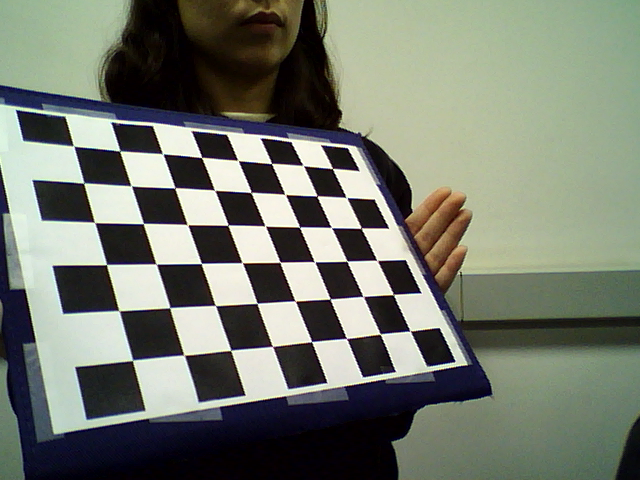

In [ ]:
# Exibe o primeiro par disponível, caso as imagens tenham sido colocadas nas pastas.
arquivosL = sorted(PASTA_ESQUERDA.glob("*.png"))
arquivosR = sorted(PASTA_DIREITA.glob("*.png"))

if arquivosL and arquivosR:
    imgL = cv2.cvtColor(cv2.imread(str(arquivosL[0])), cv2.COLOR_BGR2RGB)
    imgR = cv2.cvtColor(cv2.imread(str(arquivosR[0])), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))
    plt.imshow(np.hstack((imgL, imgR)))
    plt.axis("off")
    plt.title("Primeiro par de imagens de calibração")
    plt.show()
else:
    print("Nenhum par de imagens foi encontrado nas pastas stereoL e stereoR.")

## 8. Calibração individual e estereoscópica

O procedimento foi dividido em quatro etapas:

1. criação das coordenadas tridimensionais ideais do tabuleiro;
2. detecção e refinamento subpixel dos cantos nas duas imagens;
3. calibração individual das câmeras;
4. calibração conjunta e retificação.

Na implementação enviada, o padrão possui 8 colunas e 6 linhas de cantos internos, totalizando 48 pontos. Como o tamanho real do quadrado não foi informado ao programa, as coordenadas são expressas em unidades de quadrado. Por isso, a translação calculada também fica nessa unidade.

In [ ]:
PADRAO = (8, 6)
TAMANHO_QUADRADO = 1.0  # Substituir pela medida real do quadrado, se conhecida.

criterio_subpixel = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

objp = np.zeros((PADRAO[0] * PADRAO[1], 3), np.float32)
objp[:, :2] = (
    np.mgrid[0:PADRAO[0], 0:PADRAO[1]]
    .T.reshape(-1, 2) * TAMANHO_QUADRADO
)

obj_pts = []
img_ptsL = []
img_ptsR = []

arquivosL = sorted(PASTA_ESQUERDA.glob("*.png"))
arquivosR = sorted(PASTA_DIREITA.glob("*.png"))

if len(arquivosL) != len(arquivosR):
    raise ValueError(
        f"Quantidade diferente de imagens: esquerda={len(arquivosL)}, "
        f"direita={len(arquivosR)}."
    )

if not arquivosL:
    raise FileNotFoundError(
        "Adicione as imagens de calibração às pastas data/stereoL e data/stereoR."
    )

ultimo_grayL = None
ultimo_grayR = None

for caminhoL, caminhoR in zip(arquivosL, arquivosR):
    imgL = cv2.imread(str(caminhoL))
    imgR = cv2.imread(str(caminhoR))

    if imgL is None or imgR is None:
        print("Par ignorado por erro de leitura:", caminhoL.name, caminhoR.name)
        continue

    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

    retL, cornersL = cv2.findChessboardCorners(grayL, PADRAO, None)
    retR, cornersR = cv2.findChessboardCorners(grayR, PADRAO, None)

    if retL and retR:
        cornersL = cv2.cornerSubPix(
            grayL, cornersL, (11, 11), (-1, -1), criterio_subpixel
        )
        cornersR = cv2.cornerSubPix(
            grayR, cornersR, (11, 11), (-1, -1), criterio_subpixel
        )

        obj_pts.append(objp.copy())
        img_ptsL.append(cornersL)
        img_ptsR.append(cornersR)

        ultimo_grayL = grayL
        ultimo_grayR = grayR

print(f"Pares fornecidos: {len(arquivosL)}")
print(f"Pares válidos para calibração: {len(obj_pts)}")

if len(obj_pts) < 10:
    print("Atenção: recomenda-se utilizar pelo menos 10 pares válidos.")

In [ ]:
if ultimo_grayL is None or ultimo_grayR is None:
    raise RuntimeError("Nenhum par apresentou o tabuleiro detectável nas duas imagens.")

tamanho_imagem = ultimo_grayL.shape[::-1]

erroL, K_L, distL, rvecsL, tvecsL = cv2.calibrateCamera(
    obj_pts, img_ptsL, tamanho_imagem, None, None
)
erroR, K_R, distR, rvecsR, tvecsR = cv2.calibrateCamera(
    obj_pts, img_ptsR, tamanho_imagem, None, None
)

K_L_otima, roi_intrinseca_L = cv2.getOptimalNewCameraMatrix(
    K_L, distL, tamanho_imagem, 1, tamanho_imagem
)
K_R_otima, roi_intrinseca_R = cv2.getOptimalNewCameraMatrix(
    K_R, distR, tamanho_imagem, 1, tamanho_imagem
)

criterio_estereo = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

flags = cv2.CALIB_FIX_INTRINSIC

erro_estereo, K_L_est, distL_est, K_R_est, distR_est, R, T, E, F = (
    cv2.stereoCalibrate(
        obj_pts,
        img_ptsL,
        img_ptsR,
        K_L_otima,
        distL,
        K_R_otima,
        distR,
        tamanho_imagem,
        criteria=criterio_estereo,
        flags=flags
    )
)

R1, R2, P1, P2, Q, roiL, roiR = cv2.stereoRectify(
    K_L_est,
    distL_est,
    K_R_est,
    distR_est,
    tamanho_imagem,
    R,
    T,
    alpha=1
)

mapaL_x, mapaL_y = cv2.initUndistortRectifyMap(
    K_L_est, distL_est, R1, P1, tamanho_imagem, cv2.CV_16SC2
)
mapaR_x, mapaR_y = cv2.initUndistortRectifyMap(
    K_R_est, distR_est, R2, P2, tamanho_imagem, cv2.CV_16SC2
)

print("Calibração concluída.")

## 9. Parâmetros obtidos

A célula seguinte imprime os parâmetros na forma de matrizes e vetores, conforme solicitado no roteiro. Os valores dependem diretamente das imagens capturadas, das webcams utilizadas e da rigidez da montagem.

Os erros retornados por `calibrateCamera` e `stereoCalibrate` correspondem a erros RMS de reprojeção. Em geral, valores menores indicam melhor concordância entre os pontos detectados e o modelo calibrado, embora a aceitabilidade dependa da resolução e da aplicação.

In [ ]:
np.set_printoptions(precision=6, suppress=True)

parametros = {
    "Erro RMS da câmera esquerda": erroL,
    "Erro RMS da câmera direita": erroR,
    "Erro RMS da calibração estéreo": erro_estereo,
    "Matriz intrínseca esquerda K_L": K_L_est,
    "Coeficientes de distorção esquerda": distL_est,
    "Matriz intrínseca direita K_R": K_R_est,
    "Coeficientes de distorção direita": distR_est,
    "Rotação entre as câmeras R": R,
    "Translação entre as câmeras T": T,
    "Matriz essencial E": E,
    "Matriz fundamental F": F,
    "Retificação esquerda R1": R1,
    "Retificação direita R2": R2,
    "Projeção esquerda P1": P1,
    "Projeção direita P2": P2,
    "Matriz de reprojeção Q": Q,
}

for nome, valor in parametros.items():
    print(f"\n{nome}:")
    print(valor)

## 10. Verificação da retificação

Uma forma visual de verificar a retificação é colocar as imagens lado a lado e desenhar linhas horizontais. Objetos correspondentes devem aparecer aproximadamente na mesma altura nas duas imagens.

In [ ]:
indice_teste = 0

imgL = cv2.imread(str(arquivosL[indice_teste]))
imgR = cv2.imread(str(arquivosR[indice_teste]))

retificadaL = cv2.remap(
    imgL, mapaL_x, mapaL_y,
    interpolation=cv2.INTER_LANCZOS4,
    borderMode=cv2.BORDER_CONSTANT
)
retificadaR = cv2.remap(
    imgR, mapaR_x, mapaR_y,
    interpolation=cv2.INTER_LANCZOS4,
    borderMode=cv2.BORDER_CONSTANT
)

comparacao = np.hstack((retificadaL, retificadaR))

for y in range(30, comparacao.shape[0], 40):
    cv2.line(comparacao, (0, y), (comparacao.shape[1], y), (0, 255, 0), 1)

comparacao_rgb = cv2.cvtColor(comparacao, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 7))
plt.imshow(comparacao_rgb)
plt.axis("off")
plt.title("Imagens retificadas com linhas horizontais de referência")
plt.show()

## 11. Geração da imagem 3D anáglifa ao vivo

O vídeo anáglifo combina canais das duas imagens retificadas. Na implementação utilizada:

- os canais azul e verde são obtidos da câmera direita;
- o canal vermelho é obtido da câmera esquerda.

Como o OpenCV usa a ordem BGR, o canal de índice 2 corresponde ao vermelho. Os óculos anáglifos fazem com que cada olho receba predominantemente uma das perspectivas, produzindo a sensação de profundidade.

In [ ]:
CAMERA_ESQUERDA = 1
CAMERA_DIREITA = 0
ARQUIVO_XML = PASTA_DADOS / "params_py.xml"

fs = cv2.FileStorage(str(ARQUIVO_XML), cv2.FILE_STORAGE_READ)

Left_Stereo_Map_x = fs.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = fs.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = fs.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = fs.getNode("Right_Stereo_Map_y").mat()
fs.release()

if any(
    mapa is None for mapa in [
        Left_Stereo_Map_x, Left_Stereo_Map_y,
        Right_Stereo_Map_x, Right_Stereo_Map_y
    ]
):
    raise RuntimeError("O XML não contém todos os mapas de retificação.")

camL = cv2.VideoCapture(CAMERA_ESQUERDA)
camR = cv2.VideoCapture(CAMERA_DIREITA)

if not camL.isOpened() or not camR.isOpened():
    camL.release()
    camR.release()
    raise RuntimeError("Não foi possível abrir as duas câmeras.")

try:
    while True:
        retL, imgL = camL.read()
        retR, imgR = camR.read()

        if not retL or not retR:
            print("Falha na captura.")
            break

        Left_nice = cv2.remap(
            imgL, Left_Stereo_Map_x, Left_Stereo_Map_y,
            cv2.INTER_LANCZOS4, borderMode=cv2.BORDER_CONSTANT
        )
        Right_nice = cv2.remap(
            imgR, Right_Stereo_Map_x, Right_Stereo_Map_y,
            cv2.INTER_LANCZOS4, borderMode=cv2.BORDER_CONSTANT
        )

        anaglifo = Right_nice.copy()
        anaglifo[:, :, 0] = Right_nice[:, :, 0]  # azul
        anaglifo[:, :, 1] = Right_nice[:, :, 1]  # verde
        anaglifo[:, :, 2] = Left_nice[:, :, 2]   # vermelho

        anaglifo = cv2.resize(anaglifo, (700, 700))
        cv2.imshow("Imagem 3D anaglifa - ESC para sair", anaglifo)

        if cv2.waitKey(1) & 0xFF == 27:
            break
finally:
    camL.release()
    camR.release()
    cv2.destroyAllWindows()

## 12. Gravação do vídeo 3D

O código foi adaptado para gravar um vídeo anáglifo com aproximadamente 15 segundos, dentro da faixa de 10 a 20 segundos indicada no roteiro. O arquivo é inicialmente gerado em AVI com o codec XVID.

A duração automática evita que o tamanho do vídeo dependa do instante em que o usuário pressiona a tecla de saída.

In [ ]:
CAMERA_ESQUERDA = 1
CAMERA_DIREITA = 0
DURACAO_SEGUNDOS = 15
FPS = 10.0
LARGURA = 700
ALTURA = 700
ARQUIVO_SAIDA = PASTA_DADOS / "saida.avi"

camL = cv2.VideoCapture(CAMERA_ESQUERDA)
camR = cv2.VideoCapture(CAMERA_DIREITA)

if not camL.isOpened() or not camR.isOpened():
    camL.release()
    camR.release()
    raise RuntimeError("Não foi possível abrir as duas câmeras.")

fourcc = cv2.VideoWriter_fourcc(*"XVID")
writer = cv2.VideoWriter(
    str(ARQUIVO_SAIDA),
    fourcc,
    FPS,
    (LARGURA, ALTURA)
)

if not writer.isOpened():
    camL.release()
    camR.release()
    raise RuntimeError("Não foi possível criar o arquivo de vídeo.")

inicio = time.time()

try:
    while time.time() - inicio < DURACAO_SEGUNDOS:
        retL, imgL = camL.read()
        retR, imgR = camR.read()

        if not retL or not retR:
            print("Falha na captura.")
            break

        Left_nice = cv2.remap(
            imgL, Left_Stereo_Map_x, Left_Stereo_Map_y,
            cv2.INTER_LANCZOS4, borderMode=cv2.BORDER_CONSTANT
        )
        Right_nice = cv2.remap(
            imgR, Right_Stereo_Map_x, Right_Stereo_Map_y,
            cv2.INTER_LANCZOS4, borderMode=cv2.BORDER_CONSTANT
        )

        anaglifo = Right_nice.copy()
        anaglifo[:, :, 0] = Right_nice[:, :, 0]
        anaglifo[:, :, 1] = Right_nice[:, :, 1]
        anaglifo[:, :, 2] = Left_nice[:, :, 2]

        anaglifo = cv2.resize(anaglifo, (LARGURA, ALTURA))

        writer.write(anaglifo)
        cv2.imshow("Gravando video 3D - ESC para interromper", anaglifo)

        if cv2.waitKey(1) & 0xFF == 27:
            break
finally:
    camL.release()
    camR.release()
    writer.release()
    cv2.destroyAllWindows()

print("Vídeo salvo em:", ARQUIVO_SAIDA

      # !ffmpeg -y -i data/saida.avi -c:v libx264 -pix_fmt yuv420p data/saida.mp4

In [ ]:
caminho_avi = PASTA_DADOS / "saida.avi"
caminho_mp4 = PASTA_DADOS / "saida.mp4"

if caminho_mp4.exists():
    display(Video(str(caminho_mp4), embed=True, width=700))
elif caminho_avi.exists():
    display(Video(str(caminho_avi), embed=True, width=700))
else:
    print("O vídeo ainda não foi colocado na pasta data.")

## 13. Análise e discussão dos resultados

### 13.1 Comparação entre a visualização ao vivo e o vídeo gravado

Na visualização ao vivo, a percepção de profundidade tende a responder imediatamente ao movimento dos objetos e do observador. No vídeo gravado, essa percepção é preservada, mas pode ser afetada por compressão, taxa de quadros, redimensionamento e eventuais diferenças de sincronização entre as webcams.

A qualidade do efeito 3D depende principalmente:

- da calibração e da retificação;
- da distância entre as câmeras;
- da distância dos objetos;
- do alinhamento do suporte;
- da correspondência temporal entre os quadros;
- da separação dos canais de cor;
- da qualidade dos óculos anáglifos.

**Percepção individual dos integrantes:**

- **Integrante 1:** A primeira vez que fizemos, a imagem ficou inclinada, então nós refizemos a calibração e a imagem ficou reta, porém havia um delay entre as duas câmeras.
- **Integrante 2:** Ficou perceptível a imagem, porém o delay das câmeras fazia com que a imagem ficasse em câmera lenta.
- **Integrante 3:** Houve interferência por causa do delay da câmera, porém ficou claro a percepção de profundidade quando a pessoa ficava parada

**Comparação do grupo:**  
No geral a calibração foi um sucesso e ao usar os óculos anáglifo, era perceptível a profundidade. Porém havia um delay entre ambas as câmeras, o que dificultada a visualização do vídeo em movimento.

## 14. Aplicação da câmera estéreo no Trabalho Final

### Detector de postura incorreta durante o uso do computador

A câmera estereoscópica construída neste laboratório pode ser aplicada ao desenvolvimento de um detector de postura incorreta durante o uso do computador. Diferentemente de uma câmera monocular, o par estéreo fornece informações de profundidade, permitindo estimar a posição tridimensional do usuário e reduzir ambiguidades provocadas pela perspectiva.

O sistema pode detectar pontos de referência do corpo, como cabeça, ombros e tronco, nas imagens esquerda e direita. Após identificar as correspondências, a disparidade pode ser convertida em profundidade. Dessa forma, seria possível acompanhar:

- avanço da cabeça em relação aos ombros;
- inclinação lateral do tronco;
- distância entre o usuário e o monitor;
- desalinhamento entre os ombros;
- tempo de permanência em uma postura inadequada.

Uma arquitetura possível seria:

```text
Câmeras esquerda e direita
            ↓
Correção de distorção e retificação
            ↓
Detecção de pontos corporais nas duas imagens
            ↓
Correspondência e cálculo da disparidade
            ↓
Reconstrução aproximada da postura em 3D
            ↓
Cálculo de ângulos e distâncias
            ↓
Alerta visual ou sonoro
```

A aplicação é tecnicamente viável porque a calibração fornece a relação geométrica entre as câmeras. Entretanto, para um sistema confiável, seria necessário controlar a iluminação, validar a precisão da reconstrução, definir limites ergonômicos e testar diferentes usuários, roupas, cadeiras e posições.

## 15. Conclusões

O laboratório permitiu aplicar conceitos fundamentais da visão estereoscópica. A utilização de duas webcams possibilitou observar uma mesma cena a partir de perspectivas diferentes, condição necessária para a percepção de profundidade.

A calibração individual forneceu os parâmetros internos e os coeficientes de distorção das câmeras. A calibração estereoscópica determinou a rotação e a translação relativas, além das matrizes essencial e fundamental. Em seguida, a retificação alinhou as linhas epipolares, simplificando a correspondência entre as imagens.

Os mapas de retificação foram utilizados na composição de um vídeo anáglifo, no qual os canais vermelho, verde e azul foram combinados a partir das duas câmeras. O resultado pôde ser visualizado com óculos 3D anáglifos.

A qualidade final atingiu as expectativas, mesmo com uma disparidade entre a sincronização entre as webcams. O experimento também demonstrou que a câmera construída pode ser aproveitada em aplicações mais avançadas, como o monitoramento tridimensional da postura durante o uso do computador.

## 16. Declaração sobre o uso de Inteligência Artificial Generativa

Foi utilizada a ferramenta **ChatGPT, da OpenAI**, como apoio à organização do relatório em formato Jupyter Notebook, à revisão textual e à explicação dos conceitos e códigos. Os autores revisaram o conteúdo, verificaram sua compatibilidade com o experimento realizado e permanecem responsáveis pela versão final, pelos resultados apresentados e por eventuais imprecisões.

## 17. Referências

[1] LEARNOPENCV. *Introduction to Epipolar Geometry and Stereo Vision*. Disponível em: <https://learnopencv.com/introduction-to-epipolar-geometry-and-stereo-vision/>. Acesso em: ____ jul. 2026.

[2] LEARNOPENCV. *Making a Low-Cost Stereo Camera Using OpenCV*. Disponível em: <https://learnopencv.com/making-a-low-cost-stereo-camera-using-opencv/>. Acesso em: ____ jul. 2026.

[3] LEARNOPENCV. *Understanding Lens Distortion*. Disponível em: <https://learnopencv.com/understanding-lens-distortion/>. Acesso em: ____ jul. 2026.

[4] LOOP, C.; ZHANG, Z. Computing Rectifying Homographies for Stereo Vision. In: *IEEE Conference on Computer Vision and Pattern Recognition*, 1999.

[5] LEARNOPENCV. *Geometry of Image Formation*. Disponível em: <https://learnopencv.com/geometry-of-image-formation/>. Acesso em: ____ jul. 2026.

[6] CNPq. *Portaria nº 2664/2026*. Disponível em: <http://memoria2.cnpq.br/web/guest/view/-/journal_content/56_INSTANCE_0oED/10157/23142775>. Acesso em: ____ jul. 2026.

[7] OPENCV. *Camera Calibration and 3D Reconstruction*. Documentação oficial do OpenCV.